<a href="https://www.kaggle.com/code/sonawanelalitsunil/steps-tracker-predictions-ml-32-43?scriptVersionId=230826736" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/steps-tracker-dataset/steps_tracker_dataset.csv


## Title: Steps Tracker Dataset: Daily Activity and Movement Patterns

#### Description: This dataset records daily step counts, activity levels, and movement patterns collected from fitness trackers or smartphone pedometers. It includes timestamps, step counts, distance covered, calories burned, and optional metadata like user demographics, weather conditions, and activity types. Ideal for analyzing fitness trends, developing predictive models, or personalizing health recommendations.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/steps-tracker-dataset/steps_tracker_dataset.csv')

In [3]:
df.head()

,date,steps,distance_km,calories_burned,active_minutes,sleep_hours,water_intake_liters,mood
0,08/10/2022,4147,3.11,124.41,41,10.5,3.77,stressed
1,11/06/2022,323,0.24,9.69,3,6.0,1.90,sad
2,28/01/2022,6622,4.97,198.66,66,6.0,4.48,sad
3,23/03/2022,11136,8.35,334.08,111,8.0,1.08,tired
4,20/05/2022,2718,2.04,81.54,27,4.9,1.00,tired


In [4]:
df.tail()

,date,steps,distance_km,calories_burned,active_minutes,sleep_hours,water_intake_liters,mood
495,04/05/2022,17376,13.03,521.28,174,8.0,2.86,energetic
496,16/04/2022,6917,5.19,207.51,69,4.7,0.49,sad
497,08/01/2022,12247,9.19,367.41,122,9.0,0.15,happy
498,01/03/2022,8295,6.22,248.85,83,4.8,2.39,stressed
499,18/08/2022,5254,3.94,157.62,53,3.3,2.15,sad


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 500 non-null    object 
 1   steps                500 non-null    int64  
 2   distance_km          500 non-null    float64
 3   calories_burned      500 non-null    float64
 4   active_minutes       500 non-null    int64  
 5   sleep_hours          500 non-null    float64
 6   water_intake_liters  500 non-null    float64
 7   mood                 500 non-null    object 
dtypes: float64(4), int64(2), object(2)
memory usage: 31.4+ KB


In [6]:
df.describe()

,steps,distance_km,calories_burned,active_minutes,sleep_hours,water_intake_liters
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000
mean,10238.572000,7.678800,307.157160,102.40800,7.292400,2.506580
std,5829.268207,4.371964,174.878046,58.29293,1.814046,1.426296
min,26.000000,0.020000,0.780000,0.00000,3.100000,0.040000
25%,5313.250000,3.985000,159.397500,53.00000,6.000000,1.300000
50%,10699.000000,8.025000,320.970000,107.00000,7.000000,2.495000
75%,15317.500000,11.490000,459.525000,153.00000,8.225000,3.785000
max,19979.000000,14.980000,599.370000,200.00000,12.000000,5.000000


In [7]:
df.isnull().sum()

date                   0
steps                  0
distance_km            0
calories_burned        0
active_minutes         0
sleep_hours            0
water_intake_liters    0
mood                   0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.shape

(500, 8)

In [10]:
df.dtypes

date                    object
steps                    int64
distance_km            float64
calories_burned        float64
active_minutes           int64
sleep_hours            float64
water_intake_liters    float64
mood                    object
dtype: object

In [11]:
df.corr

<bound method DataFrame.corr of            date  steps  distance_km  calories_burned  active_minutes  \
0    08/10/2022   4147         3.11           124.41              41   
1    11/06/2022    323         0.24             9.69               3   
2    28/01/2022   6622         4.97           198.66              66   
3    23/03/2022  11136         8.35           334.08             111   
4    20/05/2022   2718         2.04            81.54              27   
..          ...    ...          ...              ...             ...   
495  04/05/2022  17376        13.03           521.28             174   
496  16/04/2022   6917         5.19           207.51              69   
497  08/01/2022  12247         9.19           367.41             122   
498  01/03/2022   8295         6.22           248.85              83   
499  18/08/2022   5254         3.94           157.62              53   

     sleep_hours  water_intake_liters       mood  
0           10.5                 3.77   stressed  
1

In [12]:
df.columns

Index(['date', 'steps', 'distance_km', 'calories_burned', 'active_minutes',
       'sleep_hours', 'water_intake_liters', 'mood'],
      dtype='object')

## Data visualizations

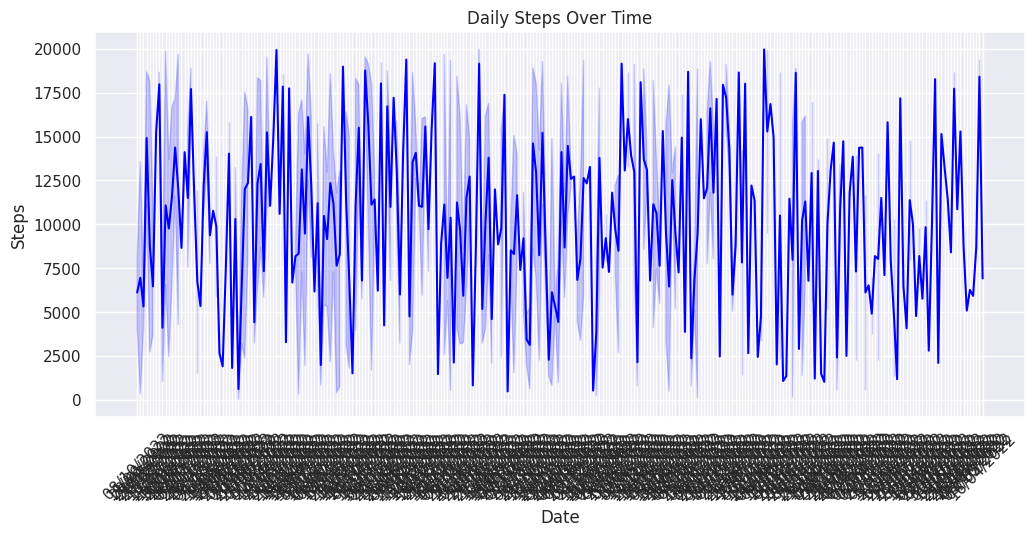

In [13]:
# Set style
sns.set_theme(style='darkgrid')

# 1. Steps Over Time
plt.figure(figsize=(12, 5))
sns.lineplot(x='date', y='steps', data=df, color='blue')
plt.title('Daily Steps Over Time')
plt.xlabel('Date')
plt.ylabel('Steps')
plt.xticks(rotation=45)
plt.show()

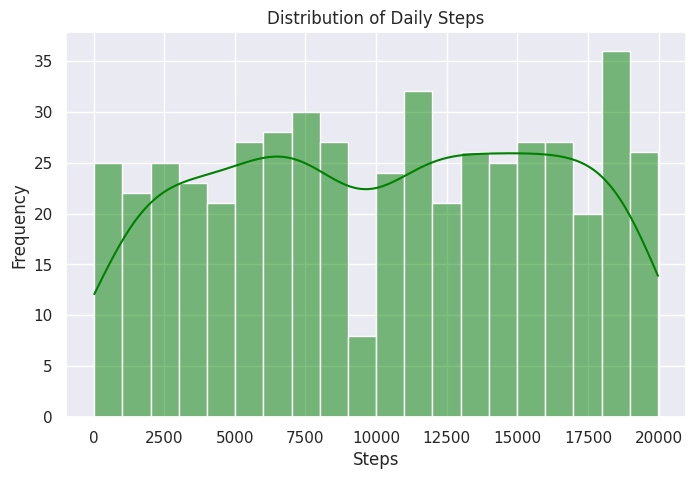

In [14]:
# 2. Histogram of Steps
plt.figure(figsize=(8, 5))
sns.histplot(df['steps'], bins=20, kde=True, color='green')
plt.title('Distribution of Daily Steps')
plt.xlabel('Steps')
plt.ylabel('Frequency')
plt.show()

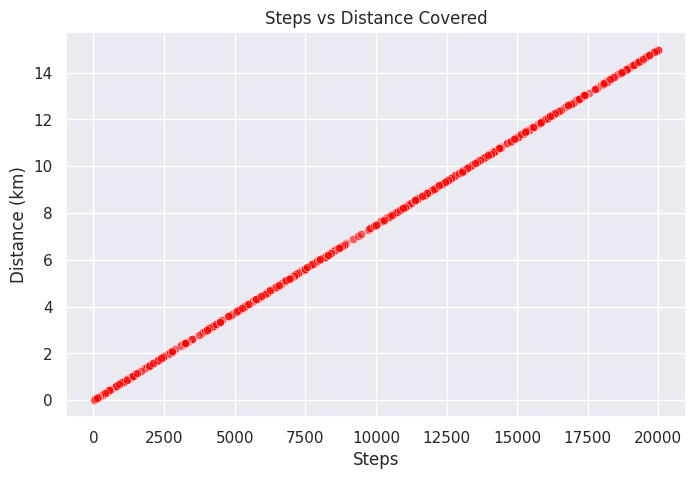

In [15]:
# 3. Scatter Plot - Steps vs Distance
plt.figure(figsize=(8, 5))
sns.scatterplot(x='steps', y='distance_km', data=df, color='red', alpha=0.6)
plt.title('Steps vs Distance Covered')
plt.xlabel('Steps')
plt.ylabel('Distance (km)')
plt.show()


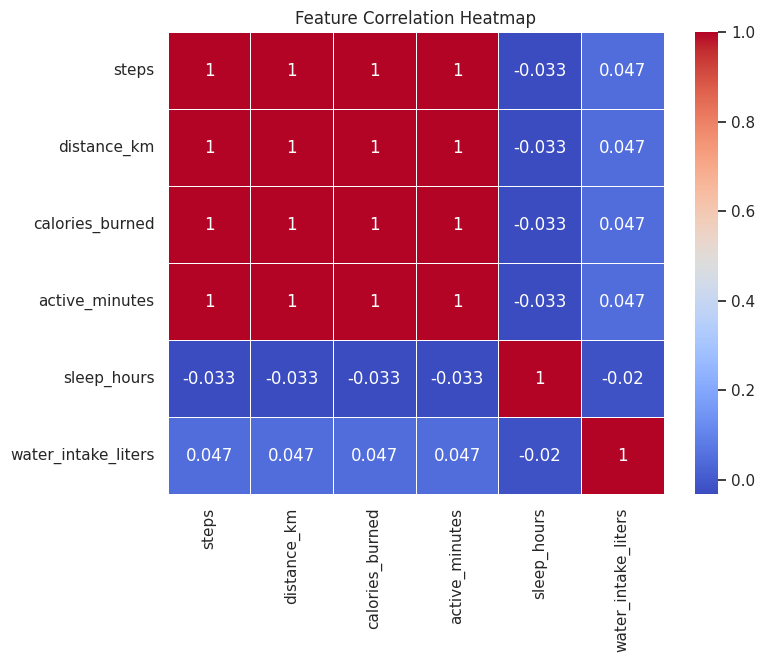

In [16]:
# 4. Heatmap of Correlations
plt.figure(figsize=(8, 6))
corr_matrix = df[['steps', 'distance_km', 'calories_burned', 'active_minutes', 'sleep_hours', 'water_intake_liters']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

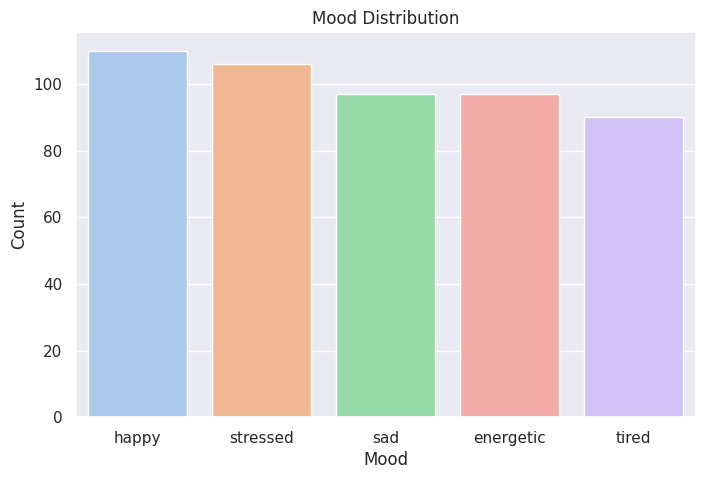

In [17]:
# 5. Mood Analysis Bar Chart
plt.figure(figsize=(8, 5))
sns.countplot(x='mood', data=df, palette='pastel', order=df['mood'].value_counts().index)
plt.title('Mood Distribution')
plt.xlabel('Mood')
plt.ylabel('Count')
plt.show()

In [18]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')  # Ensure datetime format
df['day_of_week'] = df['date'].dt.day_name()

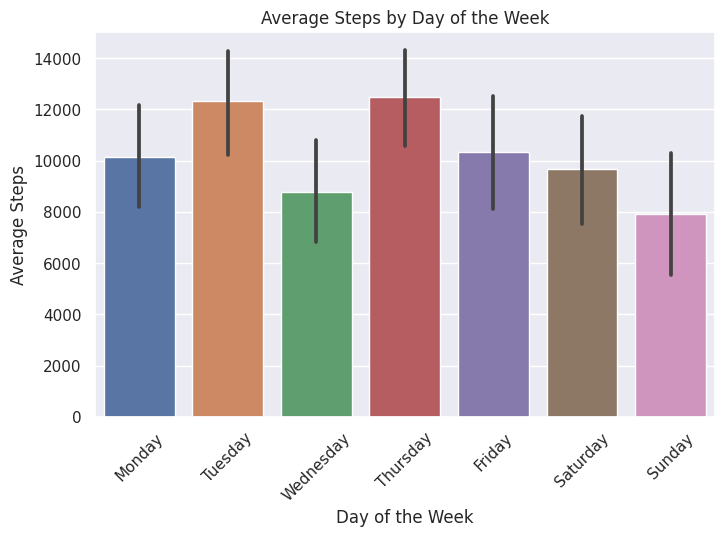

In [19]:
# 6. Steps by Day of the Week
plt.figure(figsize=(8, 5))
df['day_of_week'] = df['date'].dt.day_name()
sns.barplot(x='day_of_week', y='steps', data=df, estimator=lambda x: x.mean(), order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Average Steps by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Steps')
plt.xticks(rotation=45)
plt.show()

## Predictive modeling

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

In [21]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')  # Ensure datetime format
df.dropna(inplace=True)  # Drop missing values

In [22]:
# Encoding categorical column
label_encoder = LabelEncoder()
df['mood'] = label_encoder.fit_transform(df['mood'])

In [23]:
# Select Features and Target
X = df.drop(columns=['date', 'mood'])  # Features
y = df['mood']  # Target

In [24]:
# Ensure 'date' is in datetime format
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Create 'day_of_week' feature (if needed)
df['day_of_week'] = df['date'].dt.day_name()

# Drop unnecessary categorical columns
df.drop(columns=['date', 'day_of_week'], inplace=True)

# Encode 'mood' as a target variable
label_encoder = LabelEncoder()
df['mood'] = label_encoder.fit_transform(df['mood'])

# Features & target
X = df.drop(columns=['mood'])  # Features
y = df['mood']  # Target

# Standardize only numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [25]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [26]:
# Models to Evaluate
models = {
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier(),
    'Logistic Regression': LogisticRegression(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

In [27]:
# Train and Evaluate Models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    results[name] = acc

# Display Results
for model, acc in results.items():
    print(f'{model}: {acc:.2f}% Accuracy')

Decision Tree: 27.03% Accuracy
Random Forest: 24.32% Accuracy
SVM: 29.73% Accuracy
KNN: 32.43% Accuracy
Logistic Regression: 21.62% Accuracy
XGBoost: 27.03% Accuracy


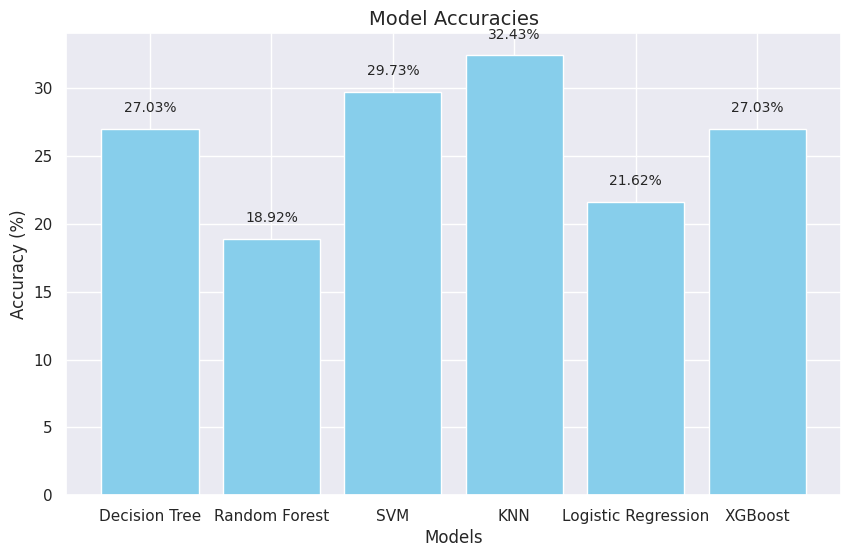

In [28]:
models = ['Decision Tree', 'Random Forest', 'SVM', 'KNN', 'Logistic Regression', 'XGBoost']
accuracies = [27.03, 18.92, 29.73, 32.43, 21.62, 27.03]

# Create bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color='skyblue')

# Add percentages on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 1, f'{yval:.2f}%', ha='center', va='bottom', fontsize=10)

# Title and labels
plt.title('Model Accuracies', fontsize=14)
plt.xlabel('Models', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)

# Show plot
plt.show()

## Thank you...pls upvote!!!!